In [6]:
import numpy as np

EPS = 1e-12


# --------------------------------------------------
# Synthetic data generator
# --------------------------------------------------
def generate_synthetic(n=10000, corr_strength=0.0, noise=0.2):
    """
    Generates:
      - embeddings (2D for visualization)
      - attribute (binary predicate)
    corr_strength in [0,1] controls how much embedding correlates with attribute.
    """

    # embeddings: two clusters + noise
    cluster = np.random.rand(n) < 0.5
    emb = np.random.randn(n, 2) * noise
    emb[cluster] += np.array([2, 2])

    # attribute correlated with cluster but not perfectly
    attr = (cluster & (np.random.rand(n) < corr_strength)) | \
           (~cluster & (np.random.rand(n) < (1 - corr_strength)))

    return emb, attr.astype(int)


# --------------------------------------------------
# Neighborhood baseline (no global stats)
# --------------------------------------------------
def neighborhood_baseline(attr, neighbors):
    """
    Baseline selectivity = average predicate rate in neighborhood.
    """
    return np.mean(attr[neighbors])


# --------------------------------------------------
# JS divergence (binary)
# --------------------------------------------------
def js_divergence(p_local, p_base):
    p_local = np.clip(p_local, EPS, 1 - EPS)
    p_base = np.clip(p_base, EPS, 1 - EPS)

    m = 0.5 * (p_local + p_base)

    kl_local = p_local * np.log(p_local / m) + (1 - p_local) * np.log((1 - p_local) / (1 - m))
    kl_base  = p_base  * np.log(p_base  / m) + (1 - p_base)  * np.log((1 - p_base)  / (1 - m))

    return 0.5 * (kl_local + kl_base)


def build_cdf(attr, bins=100):
    hist, edges = np.histogram(attr, bins=bins, density=True)
    cdf = np.cumsum(hist)
    cdf = cdf / cdf[-1]
    return edges, cdf


def cdf_prob(edges, cdf, t):
    idx = np.searchsorted(edges, t, side='right') - 1
    idx = np.clip(idx, 0, len(cdf)-1)
    return cdf[idx]

# --------------------------------------------------
# Correlation strength (direction × magnitude)
# --------------------------------------------------
def correlation_strength(p_local, p_base, k):
    """Compute signed JS strength and z-score for binary predicate."""
    direction = np.sign(p_local - p_base)
    js = js_divergence(p_local, p_base)
    z = (p_local - p_base) / np.sqrt(p_base * (1 - p_base) / max(1, k) + EPS)
    return direction * js, z, js, direction


# --------------------------------------------------
# Experiment runner
# --------------------------------------------------
def experiment(corr_strength=0.0, threshold=1):
    emb, attr = generate_synthetic(corr_strength=corr_strength)

    n = len(emb)
    results = []

    # sample queries
    idx = np.random.choice(n, size=500, replace=False)
    queries = emb[idx]

    # precompute global baseline (fraction of positives)
    global_p = np.mean(attr)

    for q in queries:
        # neighborhood (no clustering, simple kNN)
        dists = np.linalg.norm(emb - q, axis=1)
        neighbors = np.argsort(dists)[1:51]  # exclude self

        local_attr = attr[neighbors]
        p_local = np.mean(local_attr)

        # compute strength using local and global rates
        strength, z, js, direction = correlation_strength(p_local, global_p, len(neighbors))

        results.append((strength, z, js, direction))

    return np.array(results)


# --------------------------------------------------
# Run experiments
# --------------------------------------------------
res_positive = experiment(corr_strength=0.9)
res_random   = experiment(corr_strength=0.0)
res_negative = experiment(corr_strength=0.1)  # inverted-ish relation

In [ ]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans

def generate_kmeans_synthetic(emb, k=2, corr_strength=0.0):
    """
    Takes existing embeddings, runs K-Means, and generates a 
    continuous attribute (0-200) correlated with the clusters.
    """
    n = len(emb)
    
    # 1. Run K-Means to find the "hidden" structure
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    labels = kmeans.fit_predict(emb) # cluster IDs: 0, 1, ..., k-1
    
    # Normalize labels to [0, 1] to create a base signal
    # Cluster 0 -> 0.0, Cluster (k-1) -> 1.0
    cluster_signal = labels / (k - 1) if k > 1 else np.zeros(n)

    # 2. Handle Correlation Direction (-1 to 1)
    # If negative, we flip the signal (1.0 becomes 0.0)
    if corr_strength < 0:
        base_val = 1.0 - cluster_signal
    else:
        base_val = cluster_signal

    # 3. Scale to 0-200 and Mix with Noise
    # Target signal centered at ~50 (low) and ~150 (high)
    target_signal = 50 + (base_val * 100)
    
    # Random uniform noise across the full range
    random_noise = np.random.uniform(0, 200, n)
    
    # Mix based on magnitude of corr_strength
    abs_corr = abs(corr_strength)
    attr = (abs_corr * target_signal) + ((1 - abs_corr) * random_noise)
    
    # Add a little jitter so it's not perfectly flat within a cluster
    attr += np.random.randn(n) * 5
    
    return np.clip(attr, 0, 200)

# Usage:
# attr = generate_kmeans_synthetic(emb, k=2, corr_strength=0.8)

In [ ]:
from sklearn.cluster import KMeans

emb, attr = generate_kmeans_synthetic(corr_strength=0.8)
queries = emb[np.random.choice(len(emb), size=100, replace=False)]

n_clusters = 40

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init="auto"
).fit(emb)
labels = kmeans.predict(emb)
centroids = kmeans.cluster_centers_

cluster_to_indices = {
    c: np.where(labels == c)[0]
    for c in range(n_clusters)
}

def _nearest_clusters(q, top_L=10):
    distances = np.linalg.norm(centroids - q, axis=1)
    return np.argsort(distances)[:top_L]

edges, cdf = build_cdf(attr)
print(cdf_prob(edges, cdf, 0.99))



# find nearest cluster IDs for each query and flatten
cluster_ids = np.concatenate([_nearest_clusters(q) for q in queries])
local_indices = np.concatenate([cluster_to_indices[c] for c in cluster_ids])

X_local = emb[local_indices]
attr_local = attr[local_indices]

# you can now iterate through individual queries if desired
for q in queries:
    pass


0.00029999999999999987


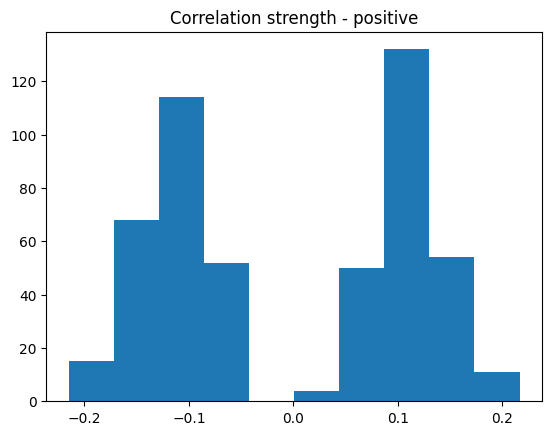

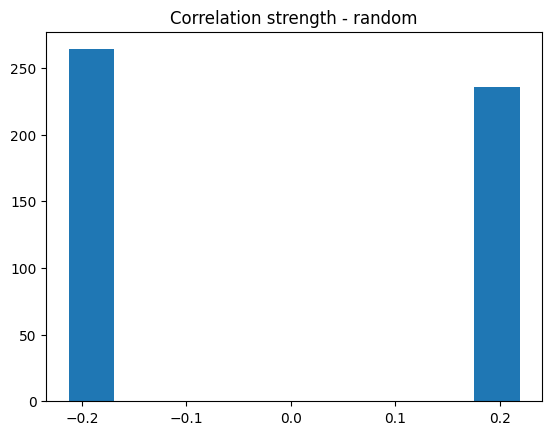

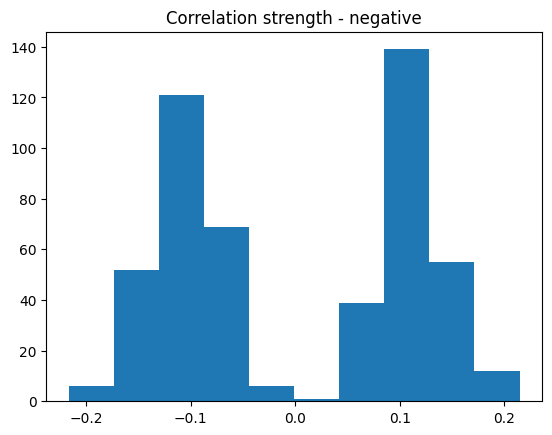

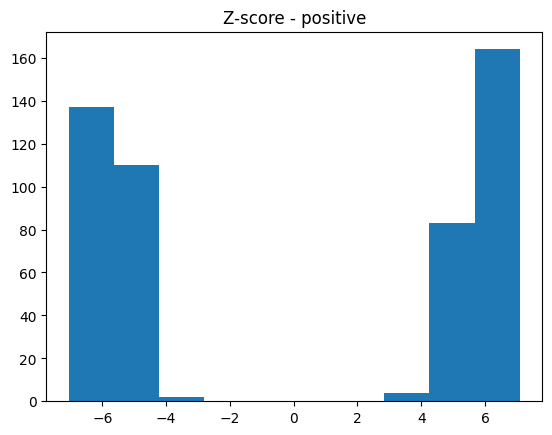

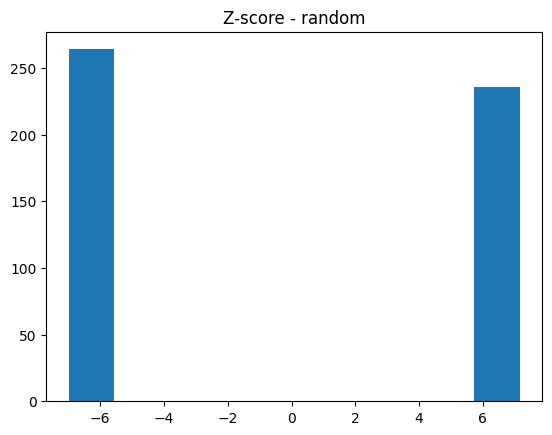

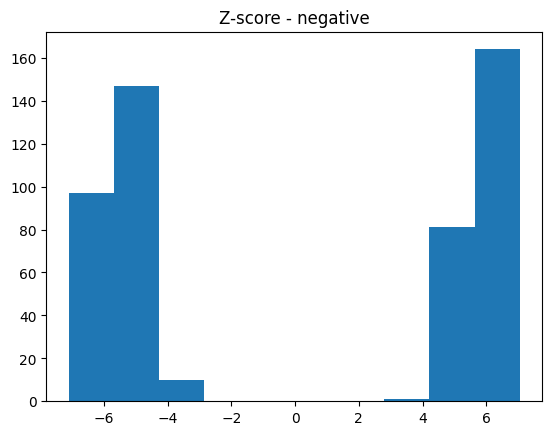

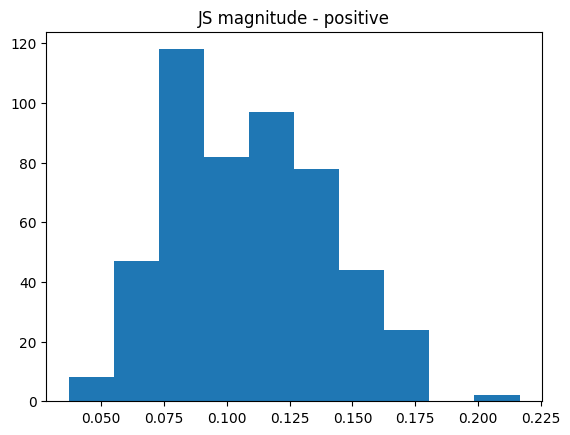

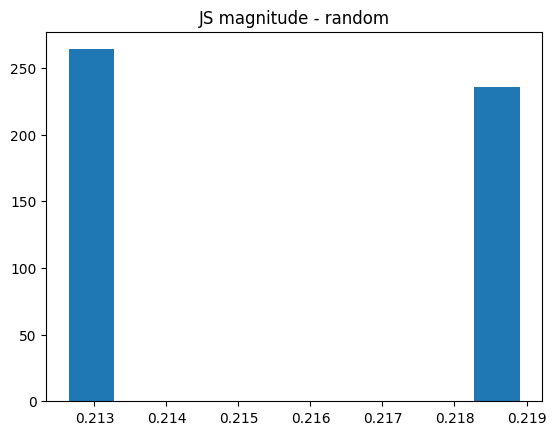

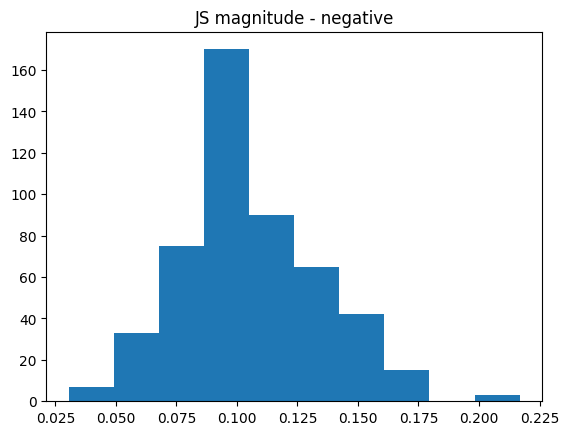

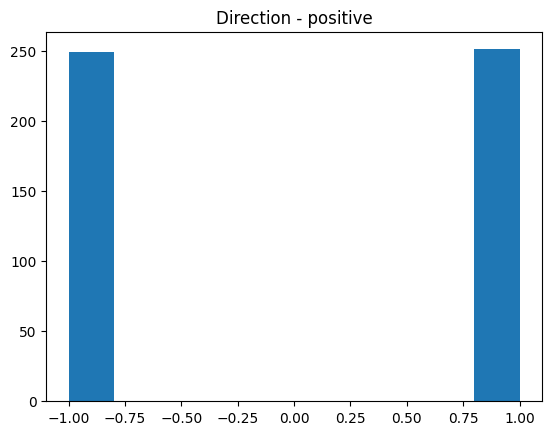

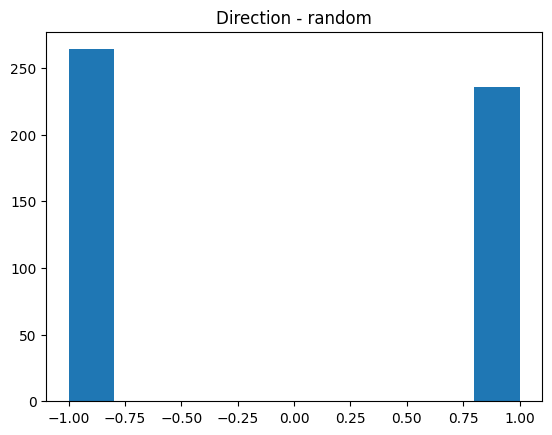

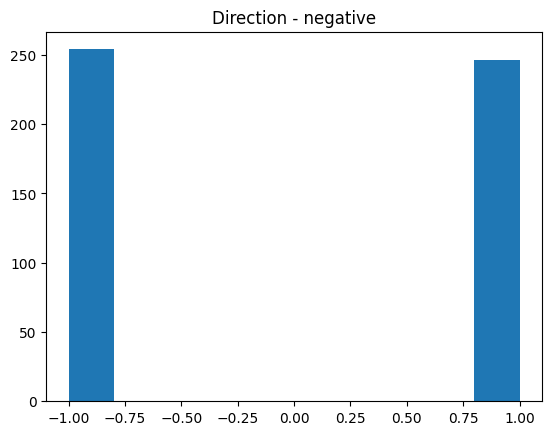

In [7]:
# --------------------------------------------------
# Plotting (separate figures)
# --------------------------------------------------

def plot_hist(data, title):
    import matplotlib.pyplot as plt
    plt.figure()
    plt.hist(data)
    plt.title(title)
    plt.show()


# Correlation strength
plot_hist(res_positive[:, 0], "Correlation strength - positive")
plot_hist(res_random[:, 0], "Correlation strength - random")
plot_hist(res_negative[:, 0], "Correlation strength - negative")

# Z-score (confidence)
plot_hist(res_positive[:, 1], "Z-score - positive")
plot_hist(res_random[:, 1], "Z-score - random")
plot_hist(res_negative[:, 1], "Z-score - negative")

# JS magnitude
plot_hist(res_positive[:, 2], "JS magnitude - positive")
plot_hist(res_random[:, 2], "JS magnitude - random")
plot_hist(res_negative[:, 2], "JS magnitude - negative")

# Direction
plot_hist(res_positive[:, 3], "Direction - positive")
plot_hist(res_random[:, 3], "Direction - random")
plot_hist(res_negative[:, 3], "Direction - negative")